### Creating baseline model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", 60)

In [3]:
df = pd.read_csv("D:/CODING/Virtual_py/PROJECTS/real_estate_ml/backend/kolkata/kolkata_post_feature_selection.csv")

In [84]:
df = df.drop(columns = ["FURNISH_LABEL", "PROPERTY_type", "CITY_LABELS"])

In [85]:
df.head()

,PREFERENCE,DESCRIPTION,BEDROOM_NUM,AGE,TOTAL_FLOOR,PROP_NAME,PROP_HEADING,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,AREA_SQFT,LATITUDE,LONGITUDE,Cooperative Society,FACING_LABEL,FACING_label_North,FACING_label_North-East,FACING_label_North-West,FACING_label_Other,FACING_label_South,FACING_label_South-East,FACING_label_West,FURNISH_label_Other,FURNISH_label_Semi-furnished,FURNISH_label_Unfurnished,PROPERTY_TYPE_Residential Apartment,PROPERTY_TYPE_Residential Land,CITY_Kolkata East,CITY_Kolkata North,CITY_Kolkata South,CITY_Kolkata West,LANDMARK_DETAILS,CITY_NUM,LOCALITY,PRICE_Cr
0,0.0,248.0,3.0,6,4.0,1601.0,542.0,42.0,29.0,2.0,2.0,1287.0,22.629509,88.479623,1,0.0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,208.0,28,284.0,0.50
1,0.0,275.0,3.0,2,15.0,415.0,489.0,42.0,8.0,1.0,7.0,1377.0,88.210954,22.493402,1,0.0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,118.0,27,199.0,0.45
2,0.0,252.0,2.0,3,3.0,174.0,84.0,43.0,48.0,4.0,3.0,810.0,22.471111,88.372903,1,6.0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,80.0,27,36.0,0.35
3,0.0,3801.0,3.0,5,3.0,819.0,540.0,45.0,50.0,1.0,1.0,1208.0,22.496720,88.370570,1,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,204.0,27,282.0,0.75
4,0.0,120.0,2.0,3,5.0,669.0,189.0,43.0,50.0,0.0,0.0,827.0,22.505744,88.356716,1,3.0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,1,0,95.0,27,189.0,0.50


In [86]:
df["Cooperative Society"].unique()

array([1, 0])

<Axes: xlabel='PRICE_Cr', ylabel='Density'>

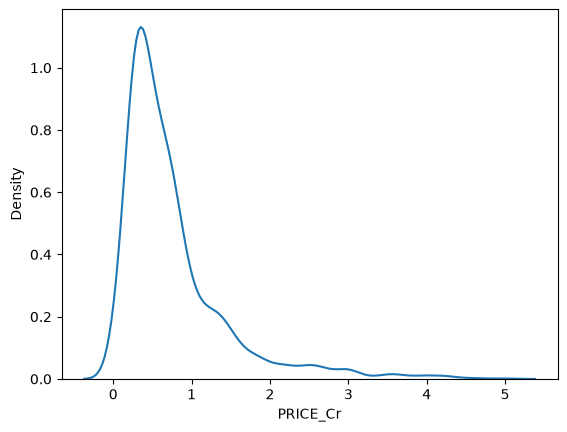

In [87]:
sns.kdeplot(df["PRICE_Cr"])     # we have to transform it

In [88]:
X = df.drop(columns = ["PRICE_Cr"])
y = df["PRICE_Cr"]


In [4]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
 

In [5]:
columns_to_encode = ["PREFERENCE", "DESCRIPTION", "PROP_NAME", "PROP_HEADING", "SECONDARY_TAGS", "LANDMARK_DETAILS", "LOCALITY"]

In [91]:
# applying log1p to priceCr
y_transformerd = np.log1p(y)

<Axes: xlabel='PRICE_Cr', ylabel='Density'>

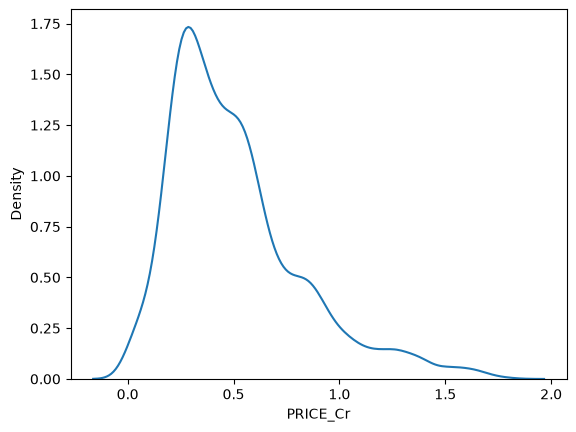

In [92]:
sns.kdeplot(y_transformerd)

In [93]:
X.head()

,PREFERENCE,DESCRIPTION,BEDROOM_NUM,AGE,TOTAL_FLOOR,PROP_NAME,PROP_HEADING,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,AREA_SQFT,LATITUDE,LONGITUDE,Cooperative Society,FACING_LABEL,FACING_label_North,FACING_label_North-East,FACING_label_North-West,FACING_label_Other,FACING_label_South,FACING_label_South-East,FACING_label_West,FURNISH_label_Other,FURNISH_label_Semi-furnished,FURNISH_label_Unfurnished,PROPERTY_TYPE_Residential Apartment,PROPERTY_TYPE_Residential Land,CITY_Kolkata East,CITY_Kolkata North,CITY_Kolkata South,CITY_Kolkata West,LANDMARK_DETAILS,CITY_NUM,LOCALITY
0,0.0,248.0,3.0,6,4.0,1601.0,542.0,42.0,29.0,2.0,2.0,1287.0,22.629509,88.479623,1,0.0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,208.0,28,284.0
1,0.0,275.0,3.0,2,15.0,415.0,489.0,42.0,8.0,1.0,7.0,1377.0,88.210954,22.493402,1,0.0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,118.0,27,199.0
2,0.0,252.0,2.0,3,3.0,174.0,84.0,43.0,48.0,4.0,3.0,810.0,22.471111,88.372903,1,6.0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,80.0,27,36.0
3,0.0,3801.0,3.0,5,3.0,819.0,540.0,45.0,50.0,1.0,1.0,1208.0,22.496720,88.370570,1,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,204.0,27,282.0
4,0.0,120.0,2.0,3,5.0,669.0,189.0,43.0,50.0,0.0,0.0,827.0,22.505744,88.356716,1,3.0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,1,0,95.0,27,189.0


In [94]:
# creating a columns transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["BEDROOM_NUM", "AGE", "TOTAL_FLOOR", "TOTAL_LANDMARK_COUNT", "BALCONY_NUM", "FLOOR_NUM", "AREA_SQFT", "CITY_NUM"]),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), columns_to_encode)
    ],
    remainder="passthrough"
)

In [95]:
models = {
    "LinearRegression": LinearRegression(),
   "SVM" : SVR(kernel="rbf"),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42)
}

In [96]:
# creatign pipeline

# pipeline = Pipeline(
#     steps = [
#         ("preprocessor", preprocessor),
#         ("regressor", LinearRegression())
#     ]
# )


In [97]:
# applying kfold cross validation
# kfold = KFold(n_splits=10, shuffle=True, random_state=42)
# scores = cross_val_score(pipeline, X, y_transformerd, cv=kfold, scoring="r2")
# results[name] = scores.mean()
# stds[name] = scores.std()

In [98]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
results = {}
stds = {}
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])


    scores = cross_val_score(pipeline, X, y_transformerd, cv=kfold, scoring="r2")
    results[name] = scores.mean()
    stds[name] = scores.std()

D:\CODING\Virtual_py\PROJECTS\real_estate_ml\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
D:\CODING\Virtual_py\PROJECTS\real_estate_ml\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
D:\CODING\Virtual_py\PROJECTS\real_estate_ml\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
D:\CODING\Virtual_py\PROJECTS\real_estate_ml\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in c

In [99]:
print(results)


{'LinearRegression': np.float64(0.8754634034681089), 'SVM': np.float64(0.7589055308936777), 'RandomForest': np.float64(0.9265747549684568)}


In [100]:
# scores.std()

print(stds)

{'LinearRegression': np.float64(0.017501420682136226), 'SVM': np.float64(0.01728441939650395), 'RandomForest': np.float64(0.00834739705291031)}


In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_transformerd, test_size=0.2, random_state=42)


In [102]:
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['PREFERENCE','DESCRIPTION','BEDROOM_NUM',...,'LANDMARK_DETAILS', 'CITY_NUM','LOCALITY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. T

In [103]:
y_pred = pipeline.predict(X_test)


D:\CODING\Virtual_py\PROJECTS\real_estate_ml\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [104]:
y_pred = np.expm1(y_pred)           # inverse of log1p

In [105]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, y_pred)


0.24975645721816797

In [106]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred)
print(mape)


0.379425501468946


### `Hyperparamerter Tuning`

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
pd.set_option("display.max_columns", 60)

In [61]:
df = pd.read_csv("D:/CODING/Virtual_py/PROJECTS/real_estate_ml/backend/kolkata/kolkata_cleaned_v5.csv")

In [62]:
df.head()

,PREFERENCE,DESCRIPTION,TRANSACT_TYPE,BEDROOM_NUM,AGE,TOTAL_FLOOR,PROP_NAME,PROP_HEADING,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,PRICE_Cr,AREA_SQFT,PRICE_PER_SQFT(INR),OWNTYPE_label,LATITUDE,LONGITUDE,Cooperative Society,Power of Attorney,Other,Leasehold,FACING_LABEL,FACING_label_North,FACING_label_North-East,FACING_label_North-West,FACING_label_Other,FACING_label_South,FACING_label_South-East,FACING_label_South-West,FACING_label_West,FURNISH_LABEL,FURNISH_label_Other,FURNISH_label_Semi-furnished,FURNISH_label_Unfurnished,PROPERTY_type,PROPERTY_TYPE_Independent/Builder Floor,PROPERTY_TYPE_Residential Apartment,PROPERTY_TYPE_Residential Land,CITY_LABELS,CITY_Kolkata East,CITY_Kolkata North,CITY_Kolkata South,CITY_Kolkata West,LANDMARK_DETAILS,CITY_NUM,LOCALITY
0,S,3bhk flat on the second floor of a four-Storey...,1.0,3.0,6,4.0,team taurus kabya,3 BHK Flat in Rajarhat,"['READY TO MOVE', 'RESALE', 'RERA | HIRA']",29.0,2.0,2.0,0.50,1287.0,3885.00,Cooperative Society,22.629509,88.479623,1,0,0,0,East,0,0,0,0,0,0,0,0,Fully furnished,0,0,0,Residential Apartment,0,1,0,Kolkata East,1,0,0,0,"['ReligiousPlace', 'Hospital', 'OfficeComplex'...",28,Rajarhat
1,S,"3bhk, 2 bath, semi-Furnished, 7th floor (Of 15...",1.0,3.0,2,15.0,eden city maheshtala,3 BHK Flat in Maheshtala,"['READY TO MOVE', 'RESALE', 'RERA | HIRA']",8.0,1.0,7.0,0.45,1377.0,3267.97,Cooperative Society,88.210954,22.493402,1,0,0,0,East,0,0,0,0,0,0,0,0,Other,1,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'Shopping', 'Connectivity', '...",27,Maheshtala
2,S,3bhk flat/apartment for sale in baisnabghata b...,1.0,2.0,3,3.0,baisnabghata,2 BHK Flat in Baishnabghata Bye Lane,"['READY TO MOVE', 'RESALE']",48.0,4.0,3.0,0.35,810.0,4320.99,Cooperative Society,22.471111,88.372903,1,0,0,0,South-East,0,0,0,0,0,1,0,0,Other,1,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'ReligiousPlace', 'ATM', 'Hos...",27,Baishnabghata Bye Lane
3,S,This is your chance to own a 3 bhk residential...,1.0,3.0,5,3.0,moana by varada group,3 BHK Flat in Raja SC Mallick ROAD,"['UNDER CONSTRUCTION', 'RESALE']",50.0,1.0,1.0,0.75,1208.0,6208.61,Cooperative Society,22.496720,88.370570,1,0,0,0,East,0,0,0,0,0,0,0,0,Fully furnished,0,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['ReligiousPlace', 'Hospital', 'Attraction']",27,Raja SC Mallick ROAD
4,S,2bhk flat/apartment for sale in lake gardens c...,1.0,2.0,3,5.0,lake gardens chs,2 BHK Flat in Lake Gardens,"['READY TO MOVE', 'RESALE']",50.0,0.0,0.0,0.50,827.0,6045.95,Cooperative Society,22.505744,88.356716,1,0,0,0,North-West,0,0,1,0,0,0,0,0,Unfurnished,0,0,1,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'ReligiousPlace', 'ATM', 'Hos...",27,Lake Gardens


In [63]:
new_df = df.drop(columns = ["OWNTYPE_label" ,"FACING_label_South-West", "Power of Attorney", "PROPERTY_TYPE_Independent/Builder Floor","Leasehold","Other","TRANSACT_TYPE"])


In [64]:
new_df.columns

Index(['PREFERENCE', 'DESCRIPTION', 'BEDROOM_NUM', 'AGE', 'TOTAL_FLOOR',
       'PROP_NAME', 'PROP_HEADING', 'SECONDARY_TAGS', 'TOTAL_LANDMARK_COUNT',
       'BALCONY_NUM', 'FLOOR_NUM', 'PRICE_Cr', 'AREA_SQFT',
       'PRICE_PER_SQFT(INR)', 'LATITUDE', 'LONGITUDE', 'Cooperative Society',
       'FACING_LABEL', 'FACING_label_North', 'FACING_label_North-East',
       'FACING_label_North-West', 'FACING_label_Other', 'FACING_label_South',
       'FACING_label_South-East', 'FACING_label_West', 'FURNISH_LABEL',
       'FURNISH_label_Other', 'FURNISH_label_Semi-furnished',
       'FURNISH_label_Unfurnished', 'PROPERTY_type',
       'PROPERTY_TYPE_Residential Apartment', 'PROPERTY_TYPE_Residential Land',
       'CITY_LABELS', 'CITY_Kolkata East', 'CITY_Kolkata North',
       'CITY_Kolkata South', 'CITY_Kolkata West', 'LANDMARK_DETAILS',
       'CITY_NUM', 'LOCALITY'],
      dtype='str')

In [65]:
train_df = new_df[['BEDROOM_NUM', 'AGE', 'TOTAL_FLOOR',
       'TOTAL_LANDMARK_COUNT',
       'BALCONY_NUM', 'FLOOR_NUM', 'PRICE_Cr', 'AREA_SQFT',
       'LATITUDE', 'LONGITUDE', 'Cooperative Society',
       'FACING_LABEL', 'FURNISH_LABEL',  'PROPERTY_type', 'CITY_LABELS', 
       'CITY_NUM', 'LOCALITY']]

In [76]:
train_df.head()

,BEDROOM_NUM,AGE,TOTAL_FLOOR,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,PRICE_Cr,AREA_SQFT,LATITUDE,LONGITUDE,Cooperative Society,FACING_LABEL,FURNISH_LABEL,PROPERTY_type,CITY_LABELS,CITY_NUM,LOCALITY
0,3.0,6,4.0,29.0,2.0,2.0,0.50,1287.0,22.629509,88.479623,1,East,Fully furnished,Residential Apartment,Kolkata East,28,Rajarhat
1,3.0,2,15.0,8.0,1.0,7.0,0.45,1377.0,88.210954,22.493402,1,East,Other,Residential Apartment,Kolkata South,27,Maheshtala
2,2.0,3,3.0,48.0,4.0,3.0,0.35,810.0,22.471111,88.372903,1,South-East,Other,Residential Apartment,Kolkata South,27,Baishnabghata Bye Lane
3,3.0,5,3.0,50.0,1.0,1.0,0.75,1208.0,22.496720,88.370570,1,East,Fully furnished,Residential Apartment,Kolkata South,27,Raja SC Mallick ROAD
4,2.0,3,5.0,50.0,0.0,0.0,0.50,827.0,22.505744,88.356716,1,North-West,Unfurnished,Residential Apartment,Kolkata South,27,Lake Gardens


In [77]:
X = train_df.drop(columns = ["PRICE_Cr"])
y = train_df["PRICE_Cr"]

In [78]:
y_transformerd = np.log1p(y)

In [79]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
 

In [80]:
param_grid = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__max_samples':[0.1, 0.25, 0.5, 1.0],
    "regressor__max_features": ["sqrt", "log2", None]
}

In [81]:
columns_to_encode = ["FACING_LABEL", "FURNISH_LABEL", "PROPERTY_type", "CITY_LABELS", "LOCALITY"]

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["BEDROOM_NUM", "AGE", "TOTAL_FLOOR", "TOTAL_LANDMARK_COUNT", "BALCONY_NUM", "FLOOR_NUM", "AREA_SQFT", "CITY_NUM"]),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),  columns_to_encode)
    ],
    remainder="passthrough"
) 



In [82]:
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor())
    ]
)

In [83]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [84]:
search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='r2', n_jobs=-1, verbose=4)

In [ ]:
search.fit(X, y_transformerd)

Fitting 10 folds for each of 192 candidates, totalling 1920 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__max_depth': [None, 10, ...], 'regressor__max_features': ['sqrt', 'log2', ...], 'regressor__max_samples': [0.1, 0.25, ...], 'regressor__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` p

In [86]:
final_pipe = search.best_estimator_

In [87]:
search.best_params_

{'regressor__max_depth': 20,
 'regressor__max_features': 'sqrt',
 'regressor__max_samples': 1.0,
 'regressor__n_estimators': 300}

In [88]:
search.best_score_

np.float64(0.9271351317409536)

> Exporting the model

In [99]:
import pickle

with open('D:/CODING/Virtual_py/PROJECTS/real_estate_ml/backend/pkl/pipeline.pkl', 'wb') as file:
    pickle.dump(final_pipe, file)

In [90]:
X.head()

,BEDROOM_NUM,AGE,TOTAL_FLOOR,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,AREA_SQFT,LATITUDE,LONGITUDE,Cooperative Society,FACING_LABEL,FURNISH_LABEL,PROPERTY_type,CITY_LABELS,CITY_NUM,LOCALITY
0,3.0,6,4.0,29.0,2.0,2.0,1287.0,22.629509,88.479623,1,East,Fully furnished,Residential Apartment,Kolkata East,28,Rajarhat
1,3.0,2,15.0,8.0,1.0,7.0,1377.0,88.210954,22.493402,1,East,Other,Residential Apartment,Kolkata South,27,Maheshtala
2,2.0,3,3.0,48.0,4.0,3.0,810.0,22.471111,88.372903,1,South-East,Other,Residential Apartment,Kolkata South,27,Baishnabghata Bye Lane
3,3.0,5,3.0,50.0,1.0,1.0,1208.0,22.496720,88.370570,1,East,Fully furnished,Residential Apartment,Kolkata South,27,Raja SC Mallick ROAD
4,2.0,3,5.0,50.0,0.0,0.0,827.0,22.505744,88.356716,1,North-West,Unfurnished,Residential Apartment,Kolkata South,27,Lake Gardens


In [93]:
y.head()

0    0.50
1    0.45
2    0.35
3    0.75
4    0.50
Name: PRICE_Cr, dtype: float64

In [91]:
with open('D:/CODING/Virtual_py/PROJECTS/real_estate_ml/backend/pkl/df.pkl', 'wb') as file:
    pickle.dump(X, file)

> Testing

In [92]:
X.columns

Index(['BEDROOM_NUM', 'AGE', 'TOTAL_FLOOR', 'TOTAL_LANDMARK_COUNT',
       'BALCONY_NUM', 'FLOOR_NUM', 'AREA_SQFT', 'LATITUDE', 'LONGITUDE',
       'Cooperative Society', 'FACING_LABEL', 'FURNISH_LABEL', 'PROPERTY_type',
       'CITY_LABELS', 'CITY_NUM', 'LOCALITY'],
      dtype='str')

In [102]:
X.iloc[1].values

array([np.float64(3.0), np.int64(2), np.float64(15.0), np.float64(8.0),
       np.float64(1.0), np.float64(7.0), np.float64(1377.0),
       np.float64(88.210954), np.float64(22.493402), np.int64(1), 'East',
       'Other', 'Residential Apartment', 'Kolkata South', np.int64(27),
       'Maheshtala'], dtype=object)

In [103]:
y[1]

np.float64(0.45)

In [104]:
# data = [[3.0, 6, 4.0, 29.0, 2.0, 2.0, 1287.0, 22.629509, 88.479623, 1, 'East', 'Fully Furnished', 'Residential Apartment', 'Kolkata East', 28, 'Rajarhat']]
data = [X.iloc[1].values]
cols = ['BEDROOM_NUM', 'AGE', 'TOTAL_FLOOR', 'TOTAL_LANDMARK_COUNT',
       'BALCONY_NUM', 'FLOOR_NUM', 'AREA_SQFT', 'LATITUDE', 'LONGITUDE',
       'Cooperative Society', 'FACING_LABEL', 'FURNISH_LABEL', 'PROPERTY_type',
       'CITY_LABELS', 'CITY_NUM', 'LOCALITY']

one_df = pd.DataFrame(data, columns=cols)

one_df

,BEDROOM_NUM,AGE,TOTAL_FLOOR,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,AREA_SQFT,LATITUDE,LONGITUDE,Cooperative Society,FACING_LABEL,FURNISH_LABEL,PROPERTY_type,CITY_LABELS,CITY_NUM,LOCALITY
0,3.0,2,15.0,8.0,1.0,7.0,1377.0,88.210954,22.493402,1,East,Other,Residential Apartment,Kolkata South,27,Maheshtala


In [105]:
with open('D:/CODING/Virtual_py/PROJECTS/real_estate_ml/backend/pkl/pipeline.pkl', 'rb') as file:
    loaded_pipeline = pickle.load(file)

pred = np.expm1(loaded_pipeline.predict(one_df))

In [106]:
pred

array([0.49084099])